# Tutorial Denoising

> denoising


In [ ]:
#| default_exp tutorial_3

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path
from bioMONAI.data import get_image_files, get_target, RandomSplitter
from bioMONAI.nets import BasicUNet, DynUNet
from bioMONAI.losses import *
from bioMONAI.losses import SSIMLoss
from bioMONAI.metrics import *
from bioMONAI.datasets import download_file


In [ ]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
device = get_device()
print(device)

cuda


### Download Data

In [ ]:
# Specify the directory where you want to save the downloaded files
output_directory = "../_data/U2OS"
# Define the base URL for the dataset
url = 'http://csbdeep.bioimagecomputing.com/example_data/snr_7_binning_2.zip'

# Download only the first two images
download_file(url, output_directory, extract=True)

The file has been downloaded and saved to: ../_data/U2OS
Decompression (if needed) has been handled automatically.


### Create Dataloader

In [ ]:

X_path = '../_data/U2OS/128a57f165e1044e34d9a6ef46e66b3c-snr_7_binning_2.zip.unzip/train/low/'
y_path = '../_data/U2OS/128a57f165e1044e34d9a6ef46e66b3c-snr_7_binning_2.zip.unzip/train/GT'

bs = 8
patch_size = 128

itemTfms = [RandCropND(patch_size), RandRot90(prob=.75), RandFlip(prob=0.5)]
batchTfms = [ScaleIntensityVariance ()]

get_target_fn = get_target(y_path, same_filename=True)

data = BioDataLoaders.from_folder(
    X_path, 
    get_target_fn, 
    valid_pct=0.05, 
    seed=42, 
    item_tfms=itemTfms,
    batch_tfms=batchTfms, 
    show_summary=False,
    bs = bs,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

train images: 2335 
validation images: 122


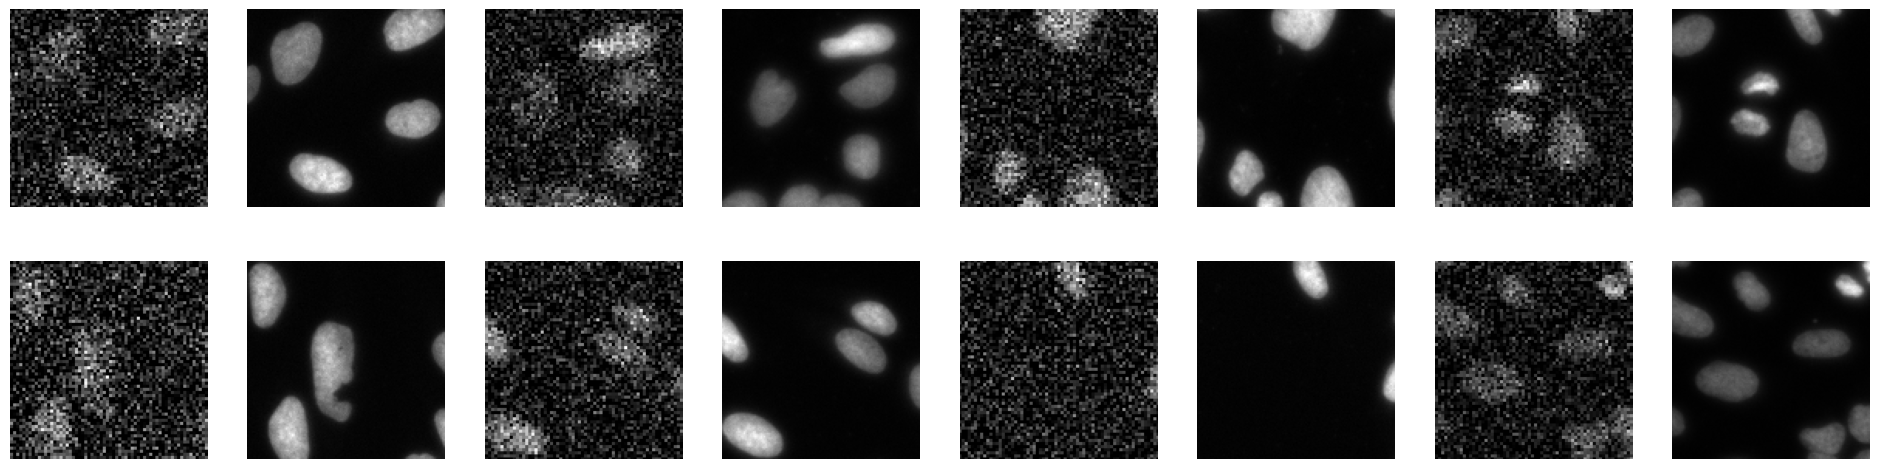

In [ ]:
data.show_batch()

### Load and train a 2D model

In [ ]:
from monai.networks.nets import UNet
# model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(32, 64, 128, 256),strides=(1, 2, 2), num_res_units=2)
model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64, 128), strides=(1, 1, 1), num_res_units=1)


In [ ]:
loss = CombinedLoss(mse_weight=0.8, mae_weight=0.1)

metrics = [MSEMetric(), MAEMetric(), SSIMMetric(2)]

trainer = fastTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=False)


epoch,train_loss,valid_loss,MSE,MAE,SSIM,time
0,0.326066,0.307889,0.273701,0.307957,0.418682,00:05
1,0.254619,0.233661,0.188537,0.272910,0.444602,00:05
2,0.195135,0.189585,0.138672,0.245747,0.459269,00:05
3,0.166921,0.156874,0.108765,0.215276,0.516660,00:05
4,0.133794,0.131164,0.081853,0.187305,0.530492,00:05
5,0.115086,0.104445,0.060321,0.152599,0.590713,00:05
6,0.102789,0.095296,0.055011,0.144148,0.631279,00:05
7,0.104722,0.107398,0.062565,0.159649,0.586190,00:05
8,0.094599,0.089968,0.052225,0.138917,0.657044,00:05
9,0.090634,0.088206,0.050685,0.137486,0.660907,00:05


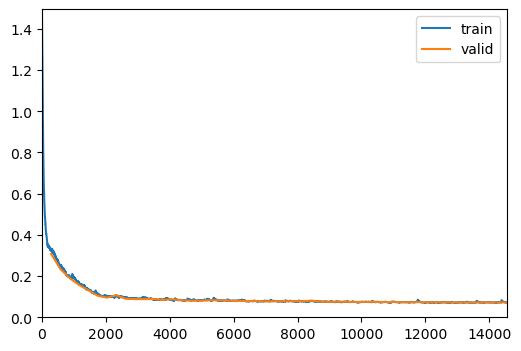

In [ ]:
trainer.fit_one_cycle(50)

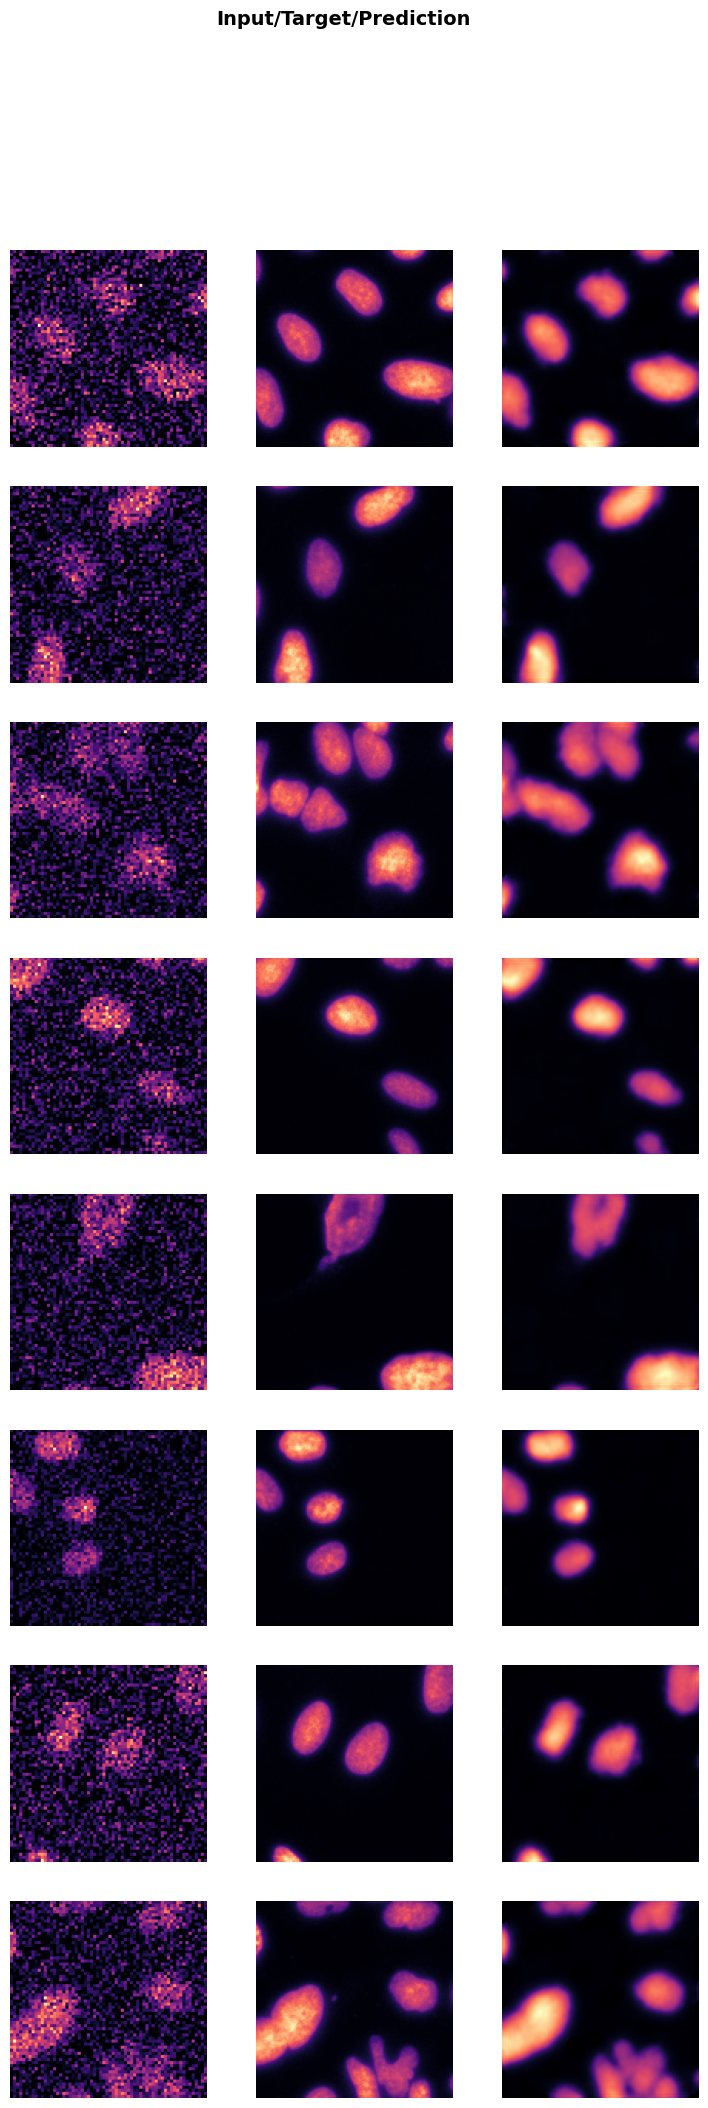

In [ ]:
trainer.show_results(cmap='magma')

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!